# Starter Sample
### Purpose: load data, inspect shapes, verify dataset logic, preview masks, confirm training setup.


In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()
_start = Path(os.getenv("PROJECT_ROOT") or Path.cwd()).resolve()
root = next(p for p in [_start, *_start.parents] if (p / "config.yaml").exists())
sys.path[:0] = [str(root), str(root / "src")]

import random

import cv2
import numpy as np
import torch

from src.data.annotations import load_json_annotations
from src.data.augmentations import get_val_augmentations
from src.data.loaders import ImageMaskDataset
from src.exploration.visualize import show_image, show_mask, show_overlay, show_side_by_side
from src.utils.config import Config
from src.utils.helpers import init_notebook, p, t

config = Config.load(root = root)

init_notebook(config.train.seed)

train_dir = config.paths.train_images
mask_dir = config.paths.train_masks
annotations_path = config.paths.annotations
entries = load_json_annotations(annotations_path)



=== init_notebook ===
Done


In [2]:
# annotation count
p("Annotation entries", len(entries))


Annotation entries: 14


#### Build simple dataset with validation transforms


In [3]:
val_tf = get_val_augmentations(config.train.image_size)
dataset = ImageMaskDataset(entries, train_dir, transform = val_tf)
p("Dataset size", len(dataset))


Dataset size: 14


#### Sample inspection

=== Image 10 ===


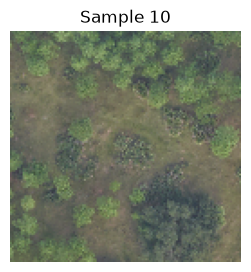

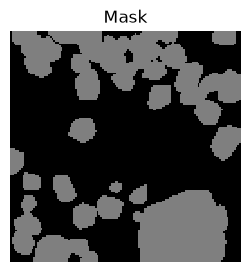

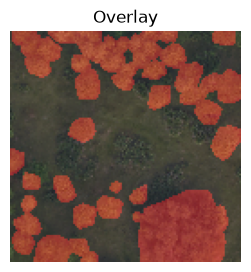

=== Checking show_side_by_side() ===


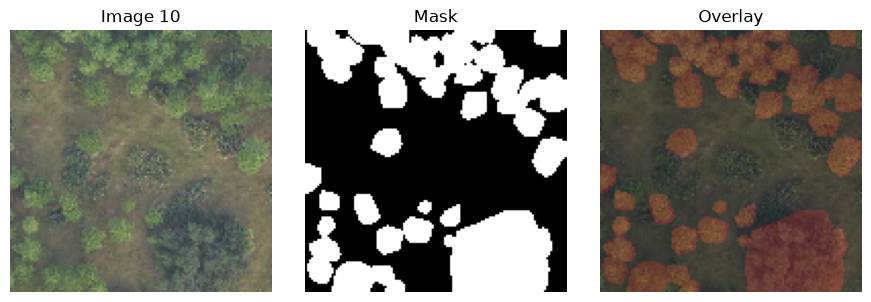

In [4]:
for _ in range(1):
    idx = random.randint(0, len(dataset) - 1)
    t(f"Image {idx}")

    img_t, mask_t = dataset[idx]

    # Handle normalized images properly for display
    if img_t.min() < 0:  # ImageNet normalized
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_denorm = torch.clamp(img_t * std + mean, 0.0, 1.0)
        img = img_denorm.permute(1, 2, 0).numpy()
    else:  # Already in [0,1] range
        img = img_t.permute(1, 2, 0).numpy()
    mask = mask_t.squeeze().numpy()

    show_image(img, f"Sample {idx}")
    show_mask(mask, "Mask")
    show_overlay(img, mask, 0.4, "Overlay")

    t("Checking show_side_by_side()")
    titles = [f"Image {idx}", f"Mask", "Overlay"]

    img_t = show_image(img, return_img = True)
    mask = show_mask(mask, return_img = True)
    overlay = show_overlay(img, mask, return_img = True)

    show_side_by_side(img, mask, overlay, titles = titles)


=== Image 1 ===


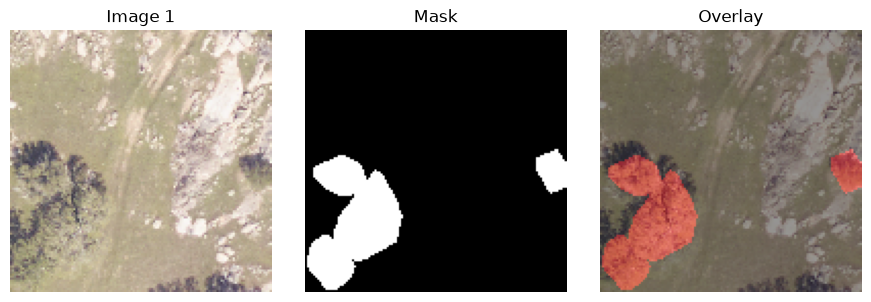

=== Image 0 ===


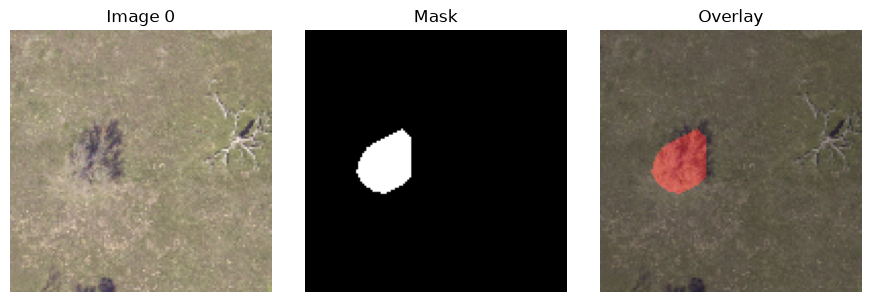

=== Image 11 ===


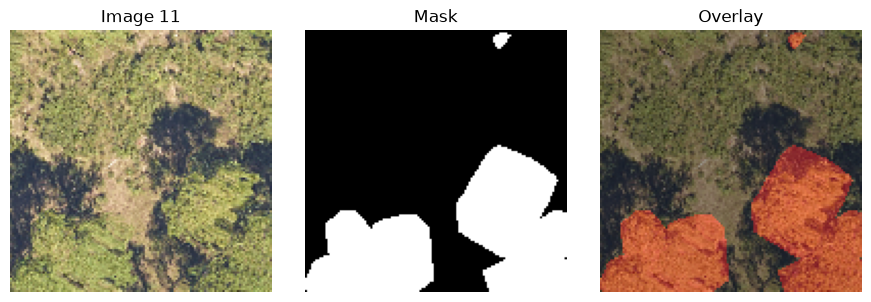

=== Image 4 ===


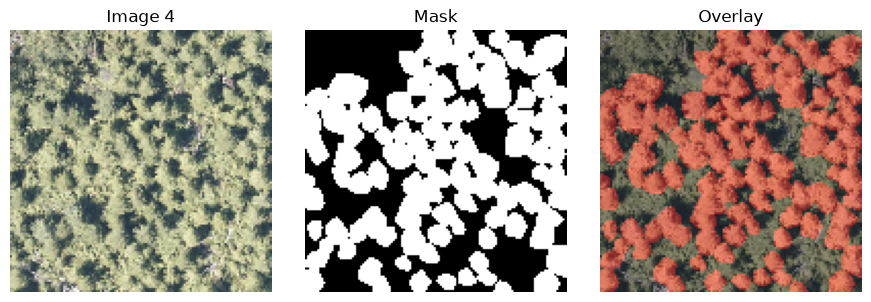

=== Image 3 ===


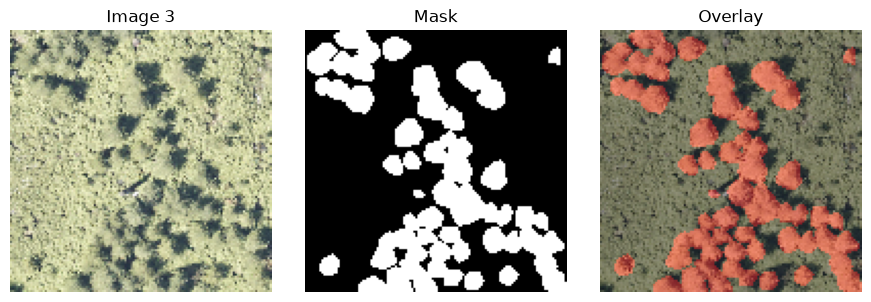

In [5]:
for _ in range(5):
    idx = random.randint(0, len(dataset) - 1)
    t(f"Image {idx}")

    img_t, mask_t = dataset[idx]

    # Handle normalized images properly for display
    if img_t.min() < 0:  # ImageNet normalized
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_denorm = torch.clamp(img_t * std + mean, 0.0, 1.0)
        img = img_denorm.permute(1, 2, 0).numpy()
    else:  # Already in [0,1] range
        img = img_t.permute(1, 2, 0).numpy()
    mask = mask_t.squeeze().numpy()

    titles = [f"Image {idx}", "Mask", "Overlay"]

    # Convert image to uint8 for cv2 operations
    if img.max() <= 1.0:
        base = (img * 255).astype(np.uint8)
    else:
        base = img.astype(np.uint8)

    # Handle mask properly for overlay
    mask_binary = (mask > 0).astype(np.uint8)  # Convert class indices to binary
    mask_rgb = np.zeros_like(base)
    mask_rgb[:, :, 0] = mask_binary * 255  # Red channel for trees
    overlay = cv2.addWeighted(base, 0.6, mask_rgb, 0.4, 0)

    show_side_by_side(img, mask, overlay, titles = titles)


#### Testing forward pass with a small model

- sample_img is a tensor shaped [3, H, W]
- sample_mask is a tensor shaped [1, H, W]

In [6]:
sample_img, sample_mask = dataset[0]


- adding a batch dimension

In [7]:
sample_img = sample_img.unsqueeze(0)


- now the image is shaped [1, 3, H, W]
- batch size is 1

In [8]:
from src.models.sample_model_provided import SampleModelProvided

model = SampleModelProvided(in_channels = 3, out_channels = 3)
model.eval()

with torch.no_grad():
    out = model(sample_img)

p("Forward pass result shape", out.shape)


Forward pass result shape: 4 items
  0: 1
  1: 3
  2: 128
  3: 128


In [9]:
model = SampleModelProvided(in_channels = 3, out_channels = 3)
model.eval()

with torch.no_grad():
    out = model(sample_img)

p("Forward pass result shape", out.shape)


Forward pass result shape: 4 items
  0: 1
  1: 3
  2: 128
  3: 128
